In [3]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

np.random.seed(42)
tf.random.set_seed(42)

print("=" * 70)
print("CELL 1/3: SETUP + DATA + TRAIN")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✅ GPU detected: {len(gpus)}")
    for gpu in gpus:
        print(f" - {gpu}")
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
else:
    print("⚠️ No GPU detected. Training will run on CPU.")

data_path = "customer_data.csv"
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Loaded dataset: {data_path} | shape={df.shape}")
else:
    print(f"⚠️ {data_path} not found. Creating synthetic dataset...")
    x_syn, y_syn = make_classification(
        n_samples=3000,
        n_features=8,
        n_informative=6,
        n_redundant=2,
        n_classes=2,
        weights=[0.7, 0.3],
        random_state=42
    )
    columns = [f"feature_{i+1}" for i in range(8)]
    df = pd.DataFrame(x_syn, columns=columns)
    df["churned"] = y_syn

if "churned" not in df.columns:
    raise ValueError("Dataset must contain a 'churned' target column")

x = df.drop("churned", axis=1).values
y = df["churned"].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(x_train)}")
print(f"Testing set size: {len(x_test)}")

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train_scaled.shape[1],), name="input_layer"),
    tf.keras.layers.Dense(32, activation="relu", name="hidden_layer_1"),
    tf.keras.layers.Dropout(0.3, name="dropout_1"),
    tf.keras.layers.Dense(16, activation="relu", name="hidden_layer_2"),
    tf.keras.layers.Dropout(0.2, name="dropout_2"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="output_layer")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

model.summary()
print("\n✅ Model compiled successfully")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras", save_best_only=True, monitor="val_loss", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, verbose=1
    ),
]

history = model.fit(
    x_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=callbacks,
)

print("\n✅ Training complete. Continue with Cell 2.")

CELL 1/3: SETUP + DATA + TRAIN
⚠️ No GPU detected. Training will run on CPU.
⚠️ customer_data.csv not found. Creating synthetic dataset...
Training set size: 2400
Testing set size: 600


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)


✅ Model compiled successfully
Epoch 1/50
50/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4187 - auc: 0.6182 - loss: 0.7785 - precision: 0.2988 - recall: 0.7659   
Epoch 1: val_loss improved from None to 0.55009, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5771 - auc: 0.6641 - loss: 0.6800 - precision: 0.3782 - recall: 0.6749 - val_accuracy: 0.7937 - val_auc: 0.8219 - val_loss: 0.5501 - val_precision: 0.7850 - val_recall: 0.5250 - learning_rate: 0.0010
Epoch 2/50
51/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7968 - auc: 0.7700 - loss: 0.5374 - precision: 0.6736 - recall: 0.5154 
Epoch 2: val_loss improved from 0.55009 to 0.41734, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - auc: 0.8198 - loss: 0.4970 - precision: 0.7193 - recall: 0.5795 - val_accuracy: 0.8479 - val_auc: 0.8982 - val_

CELL 2/3: EVALUATION + CONFUSION MATRIX + ROC
Loss:      0.2788
Accuracy:  0.9333
Precision: 0.8895
Recall:    0.8895
AUC:       0.9729

Classification Report:
              precision    recall  f1-score   support

           0     0.9523    0.9523    0.9523       419
           1     0.8895    0.8895    0.8895       181

    accuracy                         0.9333       600
   macro avg     0.9209    0.9209    0.9209       600
weighted avg     0.9333    0.9333    0.9333       600



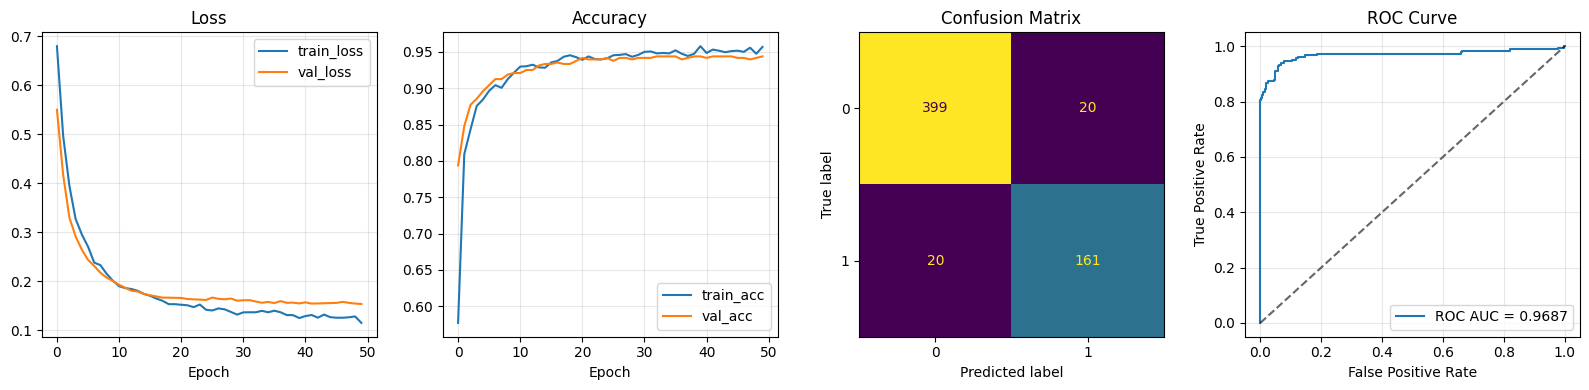


✅ Evaluation complete. Continue with Cell 3.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    )

print("=" * 70)
print("CELL 2/3: EVALUATION + THRESHOLD TUNING + CM + ROC")
print("=" * 70)

test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(
    x_test_scaled, y_test, verbose=0
)

print("Baseline metrics @ threshold=0.50")
print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"AUC:       {test_auc:.4f}")

y_prob = model.predict(x_test_scaled, verbose=0).ravel()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_values = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = int(np.argmax(f1_values))
best_threshold = float(thresholds[best_idx])

y_pred = (y_prob >= best_threshold).astype(int)
tuned_acc = accuracy_score(y_test, y_pred)
tuned_precision = precision_score(y_test, y_pred, zero_division=0)
tuned_recall = recall_score(y_test, y_pred, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nTuned metrics @ best F1 threshold")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Accuracy:       {tuned_acc:.4f}")
print(f"Precision:      {tuned_precision:.4f}")
print(f"Recall:         {tuned_recall:.4f}")
print(f"F1-score:       {tuned_f1:.4f}")

print("\nClassification Report (tuned threshold):")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 4, 2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 4, 3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=plt.gca(), colorbar=False)
plt.title("Confusion Matrix (Tuned)")

plt.subplot(1, 4, 4)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Evaluation complete. Continue with Cell 3.")

In [5]:
import pandas as pd

print("=" * 70)
print("CELL 3/3: EXPORT PREDICTIONS CSV")
print("=" * 70)

test_features_df = pd.DataFrame(
    x_test,
    columns=[col for col in df.columns if col != "churned"]
)
predictions_df = test_features_df.copy()
predictions_df["actual_churned"] = y_test
predictions_df["predicted_probability"] = y_prob
predictions_df["predicted_churned"] = y_pred

output_csv = "test_predictions.csv"
predictions_df.to_csv(output_csv, index=False)

print(f"✅ Predictions exported: {output_csv}")
print(predictions_df.head(10).to_string(index=False))

CELL 3/3: EXPORT PREDICTIONS CSV
✅ Predictions exported: test_predictions.csv
 feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  feature_7  feature_8  actual_churned  predicted_probability  predicted_churned
 -1.998089  -1.691889  -0.046930  -0.079582   1.669511  -2.341556  -4.910571  -3.747744               0           9.696547e-09                  0
 -0.336715  -2.192108  -1.830993  -2.583183   2.547923  -2.900450  -0.838276  -0.994566               0           4.699031e-07                  0
  2.337507   0.438294  -1.422080  -1.218773  -2.807900   2.014494   0.839880   2.302847               0           1.022874e-02                  0
 -0.592179   1.168574  -2.852244  -1.294224   0.518836  -2.103874   0.901664   1.182482               0           4.707483e-02                  0
  2.942977  -1.115948   0.594718  -1.551735  -2.568198   2.602581   0.338572   1.661502               0           1.504766e-06                  0
 -0.235885   1.656329  -1.117923  -1.103887  -